**Análisis de Feedback de Clientes - Tiendas Futura (Retail)**

Tiendas Futura ha implementado un nuevo sistema de recolección de comentarios en sus tótems de salida. Sin embargo, los datos están llegando con mucho "ruido" (emojis, errores de puntuación, palabras irrelevantes). Uds. son los consultores contratados para este trabajo. Tu equipo debe procesar estos datos para que el área de Marketing pueda entender qué está pasando en las tiendas.

In [1]:
comentarios_retail = [
    "¡Pésimo servicio en cajas! La cola tardó 20 minutos. :( #MalaExperiencia",
    "Me encantó la nueva colección de ropa de invierno, pero los precios están muy altos.",
    "No encontré stock de zapatillas Nike talla 42. El estante estaba vacío.",
    "La atención de los vendedores fue excelente, me ayudaron con mi cambio de talla.",
    "¿Por qué no aceptan todas las tarjetas de crédito? Es frustrante...",
    "El delivery llegó un día después de lo acordado. Mal ahí.",
    "Me gusta la variedad de productos, pero la tienda de San Isidro estaba muy desordenada.",
    "Excelente calidad en la sección de tecnología. Compré una laptop y va genial.",
    "Precios engañosos. En la etiqueta decía 50 soles y en caja me cobraron 70!!!",
    "Los probadores estaban sucios y no había nadie para ayudar."
]

In [2]:
import spacy
import pandas as pd
import nltk
from nltk.probability import FreqDist
import matplotlib.pyplot as plt

1. Unificación: Crea una variable text1 que contenga todos los comentarios unidos por un espacio.

In [3]:
text1 = ''
for comentario in comentarios_retail:
   text1 += comentario + " "
print(text1)

¡Pésimo servicio en cajas! La cola tardó 20 minutos. :( #MalaExperiencia Me encantó la nueva colección de ropa de invierno, pero los precios están muy altos. No encontré stock de zapatillas Nike talla 42. El estante estaba vacío. La atención de los vendedores fue excelente, me ayudaron con mi cambio de talla. ¿Por qué no aceptan todas las tarjetas de crédito? Es frustrante... El delivery llegó un día después de lo acordado. Mal ahí. Me gusta la variedad de productos, pero la tienda de San Isidro estaba muy desordenada. Excelente calidad en la sección de tecnología. Compré una laptop y va genial. Precios engañosos. En la etiqueta decía 50 soles y en caja me cobraron 70!!! Los probadores estaban sucios y no había nadie para ayudar. 


2. Carga el modelo es_core_news_sm y procesa text1 para crear un objeto doc. Usa Spacy

In [5]:
!pip install -U spacy
!python -m spacy download es_core_news_sm
nlp = spacy.load('es_core_news_sm')
doc = nlp(text1)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 102.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


3. Crea un DataFrame de Pandas que muestre los atributos text, lemma_, pos_ e is_stop de los primeros 10 tokens del doc (usa la estructura de tu notebook 03).

In [8]:
df = pd.DataFrame([
    {'text': token.text, 'lemma': token.lemma_, 'pos': token.pos_, 'is_stop': token.is_stop}
    for token in doc[:10]
])
print(df)

       text     lemma    pos  is_stop
0         ¡         ¡  PUNCT    False
1    Pésimo    pésimo    ADJ    False
2  servicio  servicio   NOUN    False
3        en        en    ADP     True
4     cajas      caja   NOUN    False
5         !         !  PUNCT    False
6        La        el    DET     True
7      cola      cola   NOUN    False
8     tardó    tardar   VERB    False
9        20        20    NUM    False


4. Crea una lista llamada tokens_sin_punc que contenga los tokens que NO sean puntuación (is_punct).

In [9]:
tokens_sin_punc = [token for token in doc if not token.is_punct]
print(tokens_sin_punc[:10])

[Pésimo, servicio, en, cajas, La, cola, tardó, 20, minutos, MalaExperiencia]


5. A partir de la lista anterior, crea una lista llamada tokens_sin_stop filtrando los tokens que NO sean palabras vacías (is_stop).

In [10]:
tokens_sin_stop = [token for token in tokens_sin_punc if not token.is_stop]
print(tokens_sin_stop[:10])

[Pésimo, servicio, cajas, cola, tardó, 20, minutos, MalaExperiencia, encantó, colección]


6. A partir de tokens_sin_stop, genera la lista final llamada lemas que contenga solo el lemma_ de cada token en minúsculas (.lower()).

In [11]:
lemas = [token.lemma_.lower() for token in tokens_sin_stop]
print(lemas[:10])

['pésimo', 'servicio', 'caja', 'cola', 'tardar', '20', 'minuto', 'malaexperiencia', 'encantar', 'colección']


7. Calcula el total de palabras únicas de la lista de lemas usando el comando set()

In [12]:
palabras_unicas = set(lemas)
total_palabras_unicas = len(palabras_unicas)
print(f"Total de palabras únicas: {total_palabras_unicas}")

Total de palabras únicas: 56


8. Calcula la riqueza léxica del feedback aplicando la fórmula: len(set(lemas)) / len(lemas).

In [13]:
riqueza_lexica = len(set(lemas)) / len(lemas)
print(f"Riqueza léxica: {riqueza_lexica:.2f}")

Riqueza léxica: 0.93


9. Utiliza FreqDist de NLTK para encontrar las 10 palabras (lemas) más frecuentes.

In [14]:
frecuencia_lemas = FreqDist(lemas)
print("10 lemas más frecuentes:")
for lema, frecuencia in frecuencia_lemas.most_common(10):
    print(f"{lema}: {frecuencia}")

10 lemas más frecuentes:
caja: 2
precio: 2
excelente: 2
ayudar: 2
pésimo: 1
servicio: 1
cola: 1
tardar: 1
20: 1
minuto: 1


10. Genera un gráfico de barras con el "Top 5" de frecuencias utilizando matplotlib.

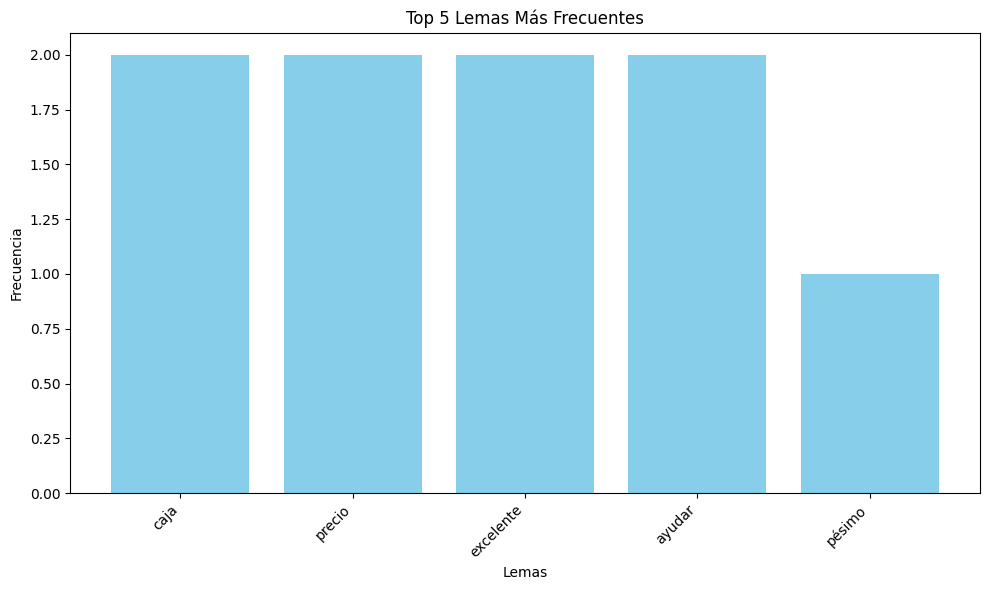

In [15]:
top_5_lemas = frecuencia_lemas.most_common(5)
lemas_grafico = [item[0] for item in top_5_lemas]
frecuencias_grafico = [item[1] for item in top_5_lemas]

plt.figure(figsize=(10, 6))
plt.bar(lemas_grafico, frecuencias_grafico, color='skyblue')
plt.xlabel('Lemas')
plt.ylabel('Frecuencia')
plt.title('Top 5 Lemas Más Frecuentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()